# Multi-task DistilBERT Fine-tuning

Joint classification of **queue** (52 cls) · **priority** (5 cls) · **type** (5 cls)

| Target | Loss weight | Metric |
|--------|-------------|--------|
| queue | 0.70 | macro-F1 |
| priority | 0.15 | accuracy |
| type | 0.15 | accuracy |

**Score** = 0.70 · MacroF1(queue) + 0.15 · Acc(priority) + 0.15 · Acc(type)

**Training protocol:**
- Epochs 1–2: encoder frozen, only classification heads trained  
- Epochs 3–5: full fine-tuning  
- AdamW lr=2e-5, cosine schedule + warmup, grad clip 1.0  
- Early stopping (patience=2) on val macro-F1(queue)

## 1. Imports & Constants

In [1]:
from __future__ import annotations

import json
import pickle
import platform
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertModel,
    DistilBertTokenizerFast,
    get_cosine_schedule_with_warmup,
)
from datasets import load_dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [7]:
# ── hyper-parameters (edit here) ─────────────────────────────────────────────
DATASET        = "Tobi-Bueck/customer-support-tickets"
MODEL_NAME     = "distilbert-base-uncased"
MAX_LENGTH     = 256
BATCH_SIZE     = 32
EPOCHS         = 5
FREEZE_EPOCHS  = 2      # encoder frozen for first N epochs
LR             = 2e-5
WEIGHT_DECAY   = 0.01
WARMUP_RATIO   = 0.10
GRAD_CLIP      = 1.0
PATIENCE       = 2      # early stopping on val macro-F1(queue)
RARE_THRESH    = 20     # apply balanced weights if any class < this

LOSS_W_QUEUE    = 0.70
LOSS_W_PRIORITY = 0.15
LOSS_W_TYPE     = 0.15

# ── device ───────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

NUM_WORKERS = 0 if platform.system() == "Darwin" else 4
PIN_MEMORY  = DEVICE.type == "cuda"

REPO_ROOT = Path("/kaggle/working")
CKPT_DIR  = Path("/kaggle/working/models")
CKPT_DIR.mkdir(exist_ok=True)

print(f"Device      : {DEVICE}")
print(f"num_workers : {NUM_WORKERS}")
print(f"pin_memory  : {PIN_MEMORY}")
print(f"repo root   : {REPO_ROOT}")

Device      : cuda
num_workers : 4
pin_memory  : True
repo root   : /kaggle/working


## 2. Data Loading

In [15]:
def read_idx(path: Path) -> np.ndarray:
    return np.loadtxt(path, dtype=np.int64)


def load_splits() -> dict[str, pd.DataFrame]:
    print("Loading dataset from HuggingFace …")
    ds = load_dataset(DATASET)["train"]
    df = ds.to_pandas()
    df["type"] = df["type"].fillna("Unknown")

    idx = {
    "train": read_idx(Path("/kaggle/input/datasets/isaevsemyon/data-index/train_idx.txt")),
    "val":   read_idx(Path("/kaggle/input/datasets/isaevsemyon/data-index/val_idx.txt")),
    "test":  read_idx(Path("/kaggle/input/datasets/isaevsemyon/data-index/test_idx.txt")),
    }
    return {k: df.iloc[v].reset_index(drop=True) for k, v in idx.items()}


def build_texts(df: pd.DataFrame) -> list[str]:
    subj = df["subject"].fillna("").astype(str)
    body = df["body"].fillna("").astype(str)
    return (subj + " [SEP] " + body).tolist()

In [16]:
splits = load_splits()
for name, df in splits.items():
    print(f"{name}: {len(df)} rows")

Loading dataset from HuggingFace …
train: 49412 rows
val: 6176 rows
test: 6177 rows


## 3. Label Encoders & Class Weights

In [17]:
def fit_label_encoders(train_df: pd.DataFrame) -> dict[str, LabelEncoder]:
    encs: dict[str, LabelEncoder] = {}
    for col in ("queue", "priority", "type"):
        le = LabelEncoder()
        le.fit(train_df[col].astype(str).values)
        encs[col] = le
    return encs


def encode_labels(
    df: pd.DataFrame,
    encs: dict[str, LabelEncoder],
) -> dict[str, np.ndarray]:
    return {col: encs[col].transform(df[col].astype(str).values) for col in encs}


def compute_class_weights(
    labels: np.ndarray, n_classes: int
) -> torch.Tensor | None:
    """Inverse-frequency weights when any class has < RARE_THRESH samples."""
    counts = np.bincount(labels, minlength=n_classes).astype(float)
    if counts.min() < RARE_THRESH:
        w = counts.sum() / (n_classes * np.maximum(counts, 1.0))
        w = np.clip(w, 0.1, 10.0)
        return torch.tensor(w, dtype=torch.float32)
    return None

In [18]:
encs = fit_label_encoders(splits["train"])
n_queue    = len(encs["queue"].classes_)
n_priority = len(encs["priority"].classes_)
n_type     = len(encs["type"].classes_)
print(f"Classes  queue={n_queue}  priority={n_priority}  type={n_type}")

# save for inference
with open(CKPT_DIR / "label_encoders.pkl", "wb") as f:
    pickle.dump(encs, f)
print("Label encoders saved.")

# class weights
train_labels = encode_labels(splits["train"], encs)
cw_q = compute_class_weights(train_labels["queue"],    n_queue)
cw_p = compute_class_weights(train_labels["priority"], n_priority)
cw_t = compute_class_weights(train_labels["type"],     n_type)
for name, cw in (("queue", cw_q), ("priority", cw_p), ("type", cw_t)):
    tag = f"weighted (min={cw.min():.3f} max={cw.max():.3f})" if cw is not None else "uniform"
    print(f"  loss({name}): {tag}")

Classes  queue=52  priority=5  type=5
Label encoders saved.
  loss(queue): uniform
  loss(priority): uniform
  loss(type): uniform


## 4. Dataset & Tokenizer

In [19]:
class TicketDataset(Dataset):
    """Tokenizes all texts upfront; returns tensors per sample."""

    def __init__(
        self,
        texts:     list[str],
        labels_q:  np.ndarray,
        labels_p:  np.ndarray,
        labels_t:  np.ndarray,
        tokenizer: DistilBertTokenizerFast,
    ):
        enc = tokenizer(
            texts,
            max_length=MAX_LENGTH,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
            return_token_type_ids=False,
        )
        self.input_ids      = enc["input_ids"]       # (N, L)
        self.attention_mask = enc["attention_mask"]  # (N, L)
        self.labels_q = torch.tensor(labels_q, dtype=torch.long)
        self.labels_p = torch.tensor(labels_p, dtype=torch.long)
        self.labels_t = torch.tensor(labels_t, dtype=torch.long)

    def __len__(self) -> int:
        return len(self.labels_q)

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
        return {
            "input_ids":      self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "label_q":        self.labels_q[idx],
            "label_p":        self.labels_p[idx],
            "label_t":        self.labels_t[idx],
        }

In [20]:
print("Loading tokenizer …")
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

def build_split_dataset(name: str) -> TicketDataset:
    df    = splits[name]
    texts = build_texts(df)
    lbl   = encode_labels(df, encs)
    print(f"  tokenizing {name} ({len(df)} rows) …", flush=True)
    return TicketDataset(
        texts, lbl["queue"], lbl["priority"], lbl["type"], tokenizer
    )

ds_train = build_split_dataset("train")
ds_val   = build_split_dataset("val")
ds_test  = build_split_dataset("test")

kw = dict(num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  **kw)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False, **kw)
dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False, **kw)

steps_per_epoch = len(dl_train)
total_steps     = EPOCHS * steps_per_epoch
print(f"\nSteps: {steps_per_epoch}/epoch × {EPOCHS} epochs = {total_steps} total")

Loading tokenizer …


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

  tokenizing train (49412 rows) …
  tokenizing val (6176 rows) …
  tokenizing test (6177 rows) …

Steps: 1545/epoch × 5 epochs = 7725 total


## 5. Model Architecture

In [21]:
class MultiTaskDistilBERT(nn.Module):
    """
    Shared DistilBERT encoder + 3 independent linear classification heads
    applied to the [CLS] token representation.
    """

    def __init__(self, n_queue: int, n_priority: int, n_type: int):
        super().__init__()
        self.encoder = DistilBertModel.from_pretrained(MODEL_NAME)
        h = self.encoder.config.hidden_size  # 768

        self.dropout       = nn.Dropout(0.1)
        self.head_queue    = nn.Linear(h, n_queue)
        self.head_priority = nn.Linear(h, n_priority)
        self.head_type     = nn.Linear(h, n_type)

    def forward(
        self,
        input_ids:      torch.Tensor,
        attention_mask: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(out.last_hidden_state[:, 0])  # [CLS]
        return (
            self.head_queue(cls),
            self.head_priority(cls),
            self.head_type(cls),
        )

    def freeze_encoder(self) -> None:
        for p in self.encoder.parameters():
            p.requires_grad = False

    def unfreeze_encoder(self) -> None:
        for p in self.encoder.parameters():
            p.requires_grad = True

    def n_trainable(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

## 6. Loss, Training & Evaluation Utilities

In [22]:
def make_criterion(weight: torch.Tensor | None) -> nn.CrossEntropyLoss:
    if weight is not None:
        return nn.CrossEntropyLoss(weight=weight.to(DEVICE))
    return nn.CrossEntropyLoss()


def combined_loss(
    logits_q: torch.Tensor, logits_p: torch.Tensor, logits_t: torch.Tensor,
    lq: torch.Tensor,       lp: torch.Tensor,       lt: torch.Tensor,
    crit_q: nn.CrossEntropyLoss,
    crit_p: nn.CrossEntropyLoss,
    crit_t: nn.CrossEntropyLoss,
) -> torch.Tensor:
    return (
        LOSS_W_QUEUE    * crit_q(logits_q, lq) +
        LOSS_W_PRIORITY * crit_p(logits_p, lp) +
        LOSS_W_TYPE     * crit_t(logits_t, lt)
    )


def build_optimizer_scheduler(
    model:        MultiTaskDistilBERT,
    n_steps:      int,
    warmup_ratio: float = WARMUP_RATIO,
) -> tuple[AdamW, object]:
    optimizer = AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=LR,
        weight_decay=WEIGHT_DECAY,
    )
    warmup = int(n_steps * warmup_ratio)
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup,
        num_training_steps=n_steps,
    )
    return optimizer, scheduler

In [23]:
def train_one_epoch(
    model:     MultiTaskDistilBERT,
    loader:    DataLoader,
    optimizer: AdamW,
    scheduler,
    crits:     tuple[nn.CrossEntropyLoss, ...],
) -> float:
    model.train()
    crit_q, crit_p, crit_t = crits
    total_loss = 0.0
    n_steps    = len(loader)

    for step, batch in enumerate(loader, 1):
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        lq = batch["label_q"].to(DEVICE)
        lp = batch["label_p"].to(DEVICE)
        lt = batch["label_t"].to(DEVICE)

        optimizer.zero_grad()
        logits_q, logits_p, logits_t = model(input_ids, attention_mask)
        loss = combined_loss(
            logits_q, logits_p, logits_t, lq, lp, lt, crit_q, crit_p, crit_t
        )
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * len(lq)

        if step % max(1, n_steps // 5) == 0:
            print(f"    step {step}/{n_steps}  loss={loss.item():.4f}", flush=True)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(
    model:  MultiTaskDistilBERT,
    loader: DataLoader,
    crits:  tuple[nn.CrossEntropyLoss, ...],
) -> dict:
    model.eval()
    crit_q, crit_p, crit_t = crits
    total_loss = 0.0

    all_lq: list[int] = []
    all_lp: list[int] = []
    all_lt: list[int] = []
    pred_q: list[int] = []
    pred_p: list[int] = []
    pred_t: list[int] = []
    prob_q_list: list[np.ndarray] = []
    prob_p_list: list[np.ndarray] = []
    prob_t_list: list[np.ndarray] = []

    for batch in loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        lq = batch["label_q"].to(DEVICE)
        lp = batch["label_p"].to(DEVICE)
        lt = batch["label_t"].to(DEVICE)

        logits_q, logits_p, logits_t = model(input_ids, attention_mask)
        loss = combined_loss(
            logits_q, logits_p, logits_t, lq, lp, lt, crit_q, crit_p, crit_t
        )
        total_loss += loss.item() * len(lq)

        all_lq.extend(lq.cpu().tolist())
        all_lp.extend(lp.cpu().tolist())
        all_lt.extend(lt.cpu().tolist())

        pred_q.extend(logits_q.argmax(dim=-1).cpu().tolist())
        pred_p.extend(logits_p.argmax(dim=-1).cpu().tolist())
        pred_t.extend(logits_t.argmax(dim=-1).cpu().tolist())

        prob_q_list.append(torch.softmax(logits_q, dim=-1).cpu().numpy())
        prob_p_list.append(torch.softmax(logits_p, dim=-1).cpu().numpy())
        prob_t_list.append(torch.softmax(logits_t, dim=-1).cpu().numpy())

    mf1_q = f1_score(all_lq, pred_q, average="macro", zero_division=0)
    acc_p = accuracy_score(all_lp, pred_p)
    acc_t = accuracy_score(all_lt, pred_t)
    score = LOSS_W_QUEUE * mf1_q + LOSS_W_PRIORITY * acc_p + LOSS_W_TYPE * acc_t

    return {
        "loss":  total_loss / len(all_lq),
        "mf1_q": mf1_q,
        "acc_p": acc_p,
        "acc_t": acc_t,
        "score": score,
        "trues": {"queue": all_lq,  "priority": all_lp,  "type": all_lt},
        "preds": {"queue": pred_q,  "priority": pred_p,  "type": pred_t},
        "probs": {
            "queue":    np.concatenate(prob_q_list, axis=0),
            "priority": np.concatenate(prob_p_list, axis=0),
            "type":     np.concatenate(prob_t_list, axis=0),
        },
    }

## 7. Model Initialization

In [24]:
crits = (make_criterion(cw_q), make_criterion(cw_p), make_criterion(cw_t))

print("Loading DistilBERT …")
model = MultiTaskDistilBERT(n_queue, n_priority, n_type).to(DEVICE)
model.freeze_encoder()
print(f"Phase-1 trainable params (heads only): {model.n_trainable():,}")
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")

# optimizer + scheduler for phase 1 (frozen encoder)
phase1_steps = FREEZE_EPOCHS * steps_per_epoch
optimizer, scheduler = build_optimizer_scheduler(model, phase1_steps)
print(f"\nPhase-1 steps: {phase1_steps}  (warmup: {int(phase1_steps * WARMUP_RATIO)})")

Loading DistilBERT …


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Phase-1 trainable params (heads only): 47,678
Total params: 66,410,558

Phase-1 steps: 3090  (warmup: 309)


## 8. Training Loop

In [25]:
t_start      = time.time()
best_mf1_q   = -1.0
patience_cnt = 0
best_ckpt    = CKPT_DIR / "best_multitask_distilbert.pt"
history: list[dict] = []

print("=" * 72)
print(f"  Multi-task DistilBERT  batch={BATCH_SIZE}  max_len={MAX_LENGTH}  "
      f"lr={LR}  freeze_epochs={FREEZE_EPOCHS}")
print("=" * 72)

for epoch in range(1, EPOCHS + 1):

    # ── phase transition: unfreeze encoder ───────────────────────────────────
    if epoch == FREEZE_EPOCHS + 1:
        print(f"\n>>> Epoch {epoch}: UNFREEZING encoder <<<")
        model.unfreeze_encoder()
        print(f"  Full-model trainable params: {model.n_trainable():,}")
        remaining = (EPOCHS - epoch + 1) * steps_per_epoch
        optimizer, scheduler = build_optimizer_scheduler(
            model, remaining, warmup_ratio=0.05
        )

    print(f"\n--- Epoch {epoch}/{EPOCHS} ---", flush=True)
    ep_t0 = time.time()

    train_loss = train_one_epoch(model, dl_train, optimizer, scheduler, crits)
    val_res    = evaluate(model, dl_val, crits)
    elapsed    = time.time() - ep_t0

    row = {
        "epoch":      epoch,
        "train_loss": round(train_loss,       4),
        "val_loss":   round(val_res["loss"],  4),
        "val_mf1_q":  round(val_res["mf1_q"], 4),
        "val_acc_p":  round(val_res["acc_p"], 4),
        "val_acc_t":  round(val_res["acc_t"], 4),
        "val_score":  round(val_res["score"], 4),
    }
    history.append(row)

    print(
        f"  train_loss={row['train_loss']:.4f}  "
        f"val_loss={row['val_loss']:.4f}  "
        f"mf1(queue)={row['val_mf1_q']:.4f}  "
        f"acc(priority)={row['val_acc_p']:.4f}  "
        f"acc(type)={row['val_acc_t']:.4f}  "
        f"score={row['val_score']:.4f}  "
        f"[{elapsed:.0f}s]"
    )

    # ── checkpoint ───────────────────────────────────────────────────────────
    if val_res["mf1_q"] > best_mf1_q:
        best_mf1_q   = val_res["mf1_q"]
        patience_cnt = 0
        torch.save({
            "epoch":       epoch,
            "model_state": model.state_dict(),
            "val_mf1_q":   best_mf1_q,
            "val_score":   val_res["score"],
            "n_queue":     n_queue,
            "n_priority":  n_priority,
            "n_type":      n_type,
        }, best_ckpt)
        print(f"  ✓ checkpoint saved  (best mf1_q={best_mf1_q:.4f})")
    else:
        patience_cnt += 1
        print(f"  no improvement  patience={patience_cnt}/{PATIENCE}")
        if patience_cnt >= PATIENCE:
            print(f"\n  Early stopping triggered at epoch {epoch}")
            break

print(f"\nTraining done in {(time.time() - t_start)/60:.1f} min")

  Multi-task DistilBERT  batch=32  max_len=256  lr=2e-05  freeze_epochs=2

--- Epoch 1/5 ---
    step 309/1545  loss=2.8581
    step 618/1545  loss=2.5984
    step 927/1545  loss=2.1651
    step 1236/1545  loss=2.3882
    step 1545/1545  loss=2.4044
  train_loss=2.5666  val_loss=2.3304  mf1(queue)=0.0072  acc(priority)=0.3831  acc(type)=0.5787  score=0.1493  [393s]
  ✓ checkpoint saved  (best mf1_q=0.0072)

--- Epoch 2/5 ---
    step 309/1545  loss=2.3137
    step 618/1545  loss=2.3662
    step 927/1545  loss=2.2845
    step 1236/1545  loss=2.2703
    step 1545/1545  loss=2.1186
  train_loss=2.3025  val_loss=2.3074  mf1(queue)=0.0072  acc(priority)=0.3831  acc(type)=0.5834  score=0.1500  [403s]
  no improvement  patience=1/2

>>> Epoch 3: UNFREEZING encoder <<<
  Full-model trainable params: 66,410,558

--- Epoch 3/5 ---
    step 309/1545  loss=1.3671
    step 618/1545  loss=1.5077
    step 927/1545  loss=1.4825
    step 1236/1545  loss=1.2868
    step 1545/1545  loss=1.2711
  train_lo

## 9. Learning Curves

,epoch,train_loss,val_loss,val_mf1_q,val_acc_p,val_acc_t,val_score
0,1,2.5666,2.3304,0.0072,0.3831,0.5787,0.1493
1,2,2.3025,2.3074,0.0072,0.3831,0.5834,0.1500
2,3,1.5807,1.2457,0.6698,0.4653,0.8308,0.6633
3,4,1.1586,1.1108,0.7825,0.5096,0.8378,0.7499
4,5,1.0372,1.0952,0.7990,0.5170,0.8381,0.7626


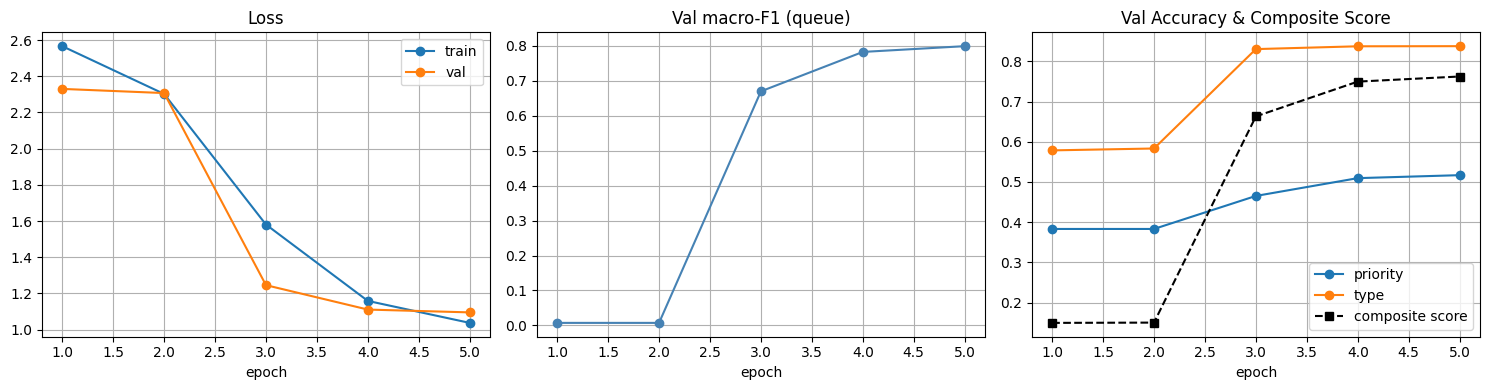

Curves saved to plots/training_curves_distilbert.png


In [30]:
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history)
display(hist_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(hist_df["epoch"], hist_df["train_loss"], marker="o", label="train")
axes[0].plot(hist_df["epoch"], hist_df["val_loss"],   marker="o", label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(hist_df["epoch"], hist_df["val_mf1_q"], marker="o", color="steelblue")
axes[1].set_title("Val macro-F1 (queue)")
axes[1].set_xlabel("epoch")
axes[1].grid(True)

axes[2].plot(hist_df["epoch"], hist_df["val_acc_p"], marker="o", label="priority")
axes[2].plot(hist_df["epoch"], hist_df["val_acc_t"], marker="o", label="type")
axes[2].plot(hist_df["epoch"], hist_df["val_score"], marker="s",
             linestyle="--", color="black", label="composite score")
axes[2].set_title("Val Accuracy & Composite Score")
axes[2].set_xlabel("epoch")
axes[2].legend()
axes[2].grid(True)

fig.tight_layout()
os.makedirs('/kaggle/working/output/plots', exist_ok=True)
plt.savefig(REPO_ROOT / "output" / "plots" / "training_curves_distilbert.png", dpi=120)
plt.show()
print("Curves saved to plots/training_curves_distilbert.png")

## 10. Test Evaluation

In [31]:
print("Loading best checkpoint …")
ckpt = torch.load(best_ckpt, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state"])
print(f"  Best epoch : {ckpt['epoch']}")
print(f"  val_mf1_q  : {ckpt['val_mf1_q']:.4f}")
print(f"  val_score  : {ckpt['val_score']:.4f}")

test_res = evaluate(model, dl_test, crits)

print("\n" + "=" * 50)
print("TEST RESULTS")
print(f"  test_loss         = {test_res['loss']:.4f}")
print(f"  queue  macro-F1   = {test_res['mf1_q']:.4f}")
print(f"  priority accuracy = {test_res['acc_p']:.4f}")
print(f"  type accuracy     = {test_res['acc_t']:.4f}")
print(f"  composite score   = {test_res['score']:.4f}")
print("=" * 50)

Loading best checkpoint …
  Best epoch : 5
  val_mf1_q  : 0.7990
  val_score  : 0.7626

TEST RESULTS
  test_loss         = 1.0875
  queue  macro-F1   = 0.7960
  priority accuracy = 0.5032
  type accuracy     = 0.8341
  composite score   = 0.7578


In [32]:
queue_classes = encs["queue"].classes_.tolist()
print("--- classification_report: queue ---")
print(classification_report(
    test_res["trues"]["queue"],
    test_res["preds"]["queue"],
    target_names=queue_classes,
    zero_division=0,
))

--- classification_report: queue ---
                                        precision    recall  f1-score   support

           Arts & Entertainment/Movies       0.86      0.92      0.89        26
            Arts & Entertainment/Music       0.77      0.96      0.85        24
          Autos & Vehicles/Maintenance       0.83      0.73      0.78        26
                Autos & Vehicles/Sales       0.89      0.87      0.88        38
            Beauty & Fitness/Cosmetics       0.95      0.88      0.91        24
     Beauty & Fitness/Fitness Training       1.00      0.92      0.96        26
                  Billing and Payments       0.74      0.71      0.73       532
            Books & Literature/Fiction       1.00      0.86      0.92        28
        Books & Literature/Non-Fiction       0.85      0.97      0.91        36
   Business & Industrial/Manufacturing       0.79      1.00      0.88        33
                      Customer Service       0.33      0.34      0.33       766
  

## 11. Save Predictions & Results

In [33]:
# save predictions + softmax probabilities for confidence analysis
payload = {
    "trues":  test_res["trues"],
    "preds":  test_res["preds"],
    "probs":  test_res["probs"],   # softmax, shape (N, n_classes) per target
    "label_classes": {k: encs[k].classes_.tolist() for k in encs},
    "metrics": {
        "test_mf1_q":  test_res["mf1_q"],
        "test_acc_p":  test_res["acc_p"],
        "test_acc_t":  test_res["acc_t"],
        "test_score":  test_res["score"],
    },
    "history": history,
}
pred_path = Path("/kaggle/working/predictions_transformer.pkl")
with open(pred_path, "wb") as f:
    pickle.dump(payload, f)
print(f"Predictions saved  →  {pred_path}")

# append to results JSON
results_path = Path("/kaggle/working/results_tfidf.json")
results: dict = {}
if results_path.exists():
    with open(results_path) as f:
        results = json.load(f)

results["multitask_distilbert"] = {
    "test_mf1_q":     test_res["mf1_q"],
    "test_acc_p":     test_res["acc_p"],
    "test_acc_t":     test_res["acc_t"],
    "test_score":     test_res["score"],
    "best_val_mf1_q": ckpt["val_mf1_q"],
    "best_val_score": ckpt["val_score"],
    "history":        history,
}
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"Results saved      →  {results_path}")

Predictions saved  →  /kaggle/working/predictions_transformer.pkl
Results saved      →  /kaggle/working/results_tfidf.json


## 12. Comparison with TF-IDF Baseline

In [34]:
results_path = Path("/kaggle/working/results_tfidf.json")
with open(results_path) as f:
    all_results = json.load(f)

rows = []
for model_key, res in all_results.items():
    if isinstance(res, dict) and "test_score" in res:
        rows.append({
            "model":        model_key,
            "queue_mf1":    res.get("test_mf1_q",  res.get("queue_macro_f1", float("nan"))),
            "priority_acc": res.get("test_acc_p",  res.get("priority_acc",   float("nan"))),
            "type_acc":     res.get("test_acc_t",  res.get("type_acc",       float("nan"))),
            "score":        res.get("test_score"),
        })

cmp_df = pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
display(cmp_df.style.format({
    "queue_mf1":    "{:.4f}",
    "priority_acc": "{:.4f}",
    "type_acc":     "{:.4f}",
    "score":        "{:.4f}",
}).highlight_max(subset=["score", "queue_mf1"], color="lightgreen"))

,model,queue_mf1,priority_acc,type_acc,score
0,multitask_distilbert,0.7960,0.5032,0.8341,0.7578
